# Diabetes Early Detection — Exploratory Analysis & Results Walkthrough

This notebook accompanies `src/train_models.py` and `src/make_charts.py`. It walks through the dataset, preprocessing decisions, and final results interactively — useful for exploring the data directly rather than only reading the finished charts.

Part of the research paper: *"Artificial Intelligence for Early Detection of Disease: A Study on Diabetes, Cardiovascular Disease, Skin Cancer, and Breast Cancer."*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## 1. Load the raw data

In [2]:
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
           "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv("../data/diabetes.csv", header=None, names=columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(f"Shape: {df.shape}")
print(f"\nClass balance:")
print(df['Outcome'].value_counts())
print(f"\nDiabetic: {df['Outcome'].mean()*100:.1f}%")

Shape: (768, 9)

Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetic: 34.9%


## 2. Check for the hidden missing-value problem

Several columns use `0` as a placeholder for missing data — not a real measurement. A blood pressure of 0 isn't compatible with being alive, so these need to be treated as missing rather than taken at face value.

In [4]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_as_missing:
    n_zero = (df[col] == 0).sum()
    print(f"{col}: {n_zero} zero-values ({n_zero/len(df)*100:.1f}% of dataset)")

Glucose: 5 zero-values (0.7% of dataset)
BloodPressure: 35 zero-values (4.6% of dataset)
SkinThickness: 227 zero-values (29.6% of dataset)
Insulin: 374 zero-values (48.7% of dataset)
BMI: 11 zero-values (1.4% of dataset)


Insulin and SkinThickness have a lot of missing data (about half and a third of the dataset, respectively) — worth keeping in mind when interpreting how much those two features can really contribute to the model.

## 3. Correlation heatmap — which features actually relate to diabetes?

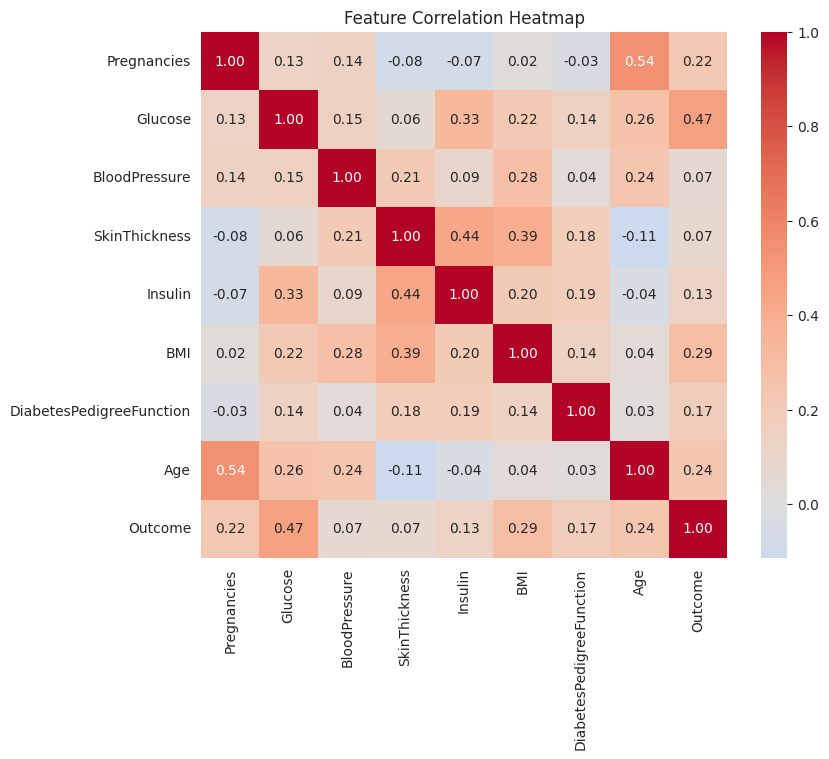

In [5]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Glucose has the strongest correlation with Outcome (0.47) of any single feature — this is worth remembering when we get to feature importance later, since the model independently arrives at the same conclusion.

## 4. Class distribution

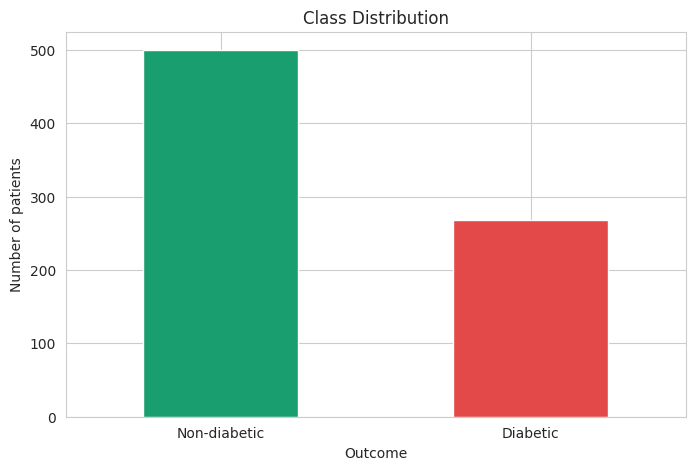

In [6]:
df['Outcome'].value_counts().plot(kind='bar', color=['#199e70', '#e34948'])
plt.xticks([0, 1], ['Non-diabetic', 'Diabetic'], rotation=0)
plt.ylabel("Number of patients")
plt.title("Class Distribution")
plt.show()

The dataset is imbalanced (roughly 2:1 non-diabetic to diabetic) — this is exactly why accuracy alone can be misleading, and why this project reports precision, recall, and F1 alongside it.

## 5. Distribution of key features, split by outcome

/tmp/ipykernel_605/34696431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y=feature, ax=ax, palette=["#199e70", "#e34948"])
/tmp/ipykernel_605/34696431.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-diabetic", "Diabetic"])
/tmp/ipykernel_605/34696431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y=feature, ax=ax, palette=["#199e70", "#e34948"])
/tmp/ipykernel_605/34696431.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabel

/tmp/ipykernel_605/34696431.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-diabetic", "Diabetic"])
/tmp/ipykernel_605/34696431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y=feature, ax=ax, palette=["#199e70", "#e34948"])
/tmp/ipykernel_605/34696431.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-diabetic", "Diabetic"])


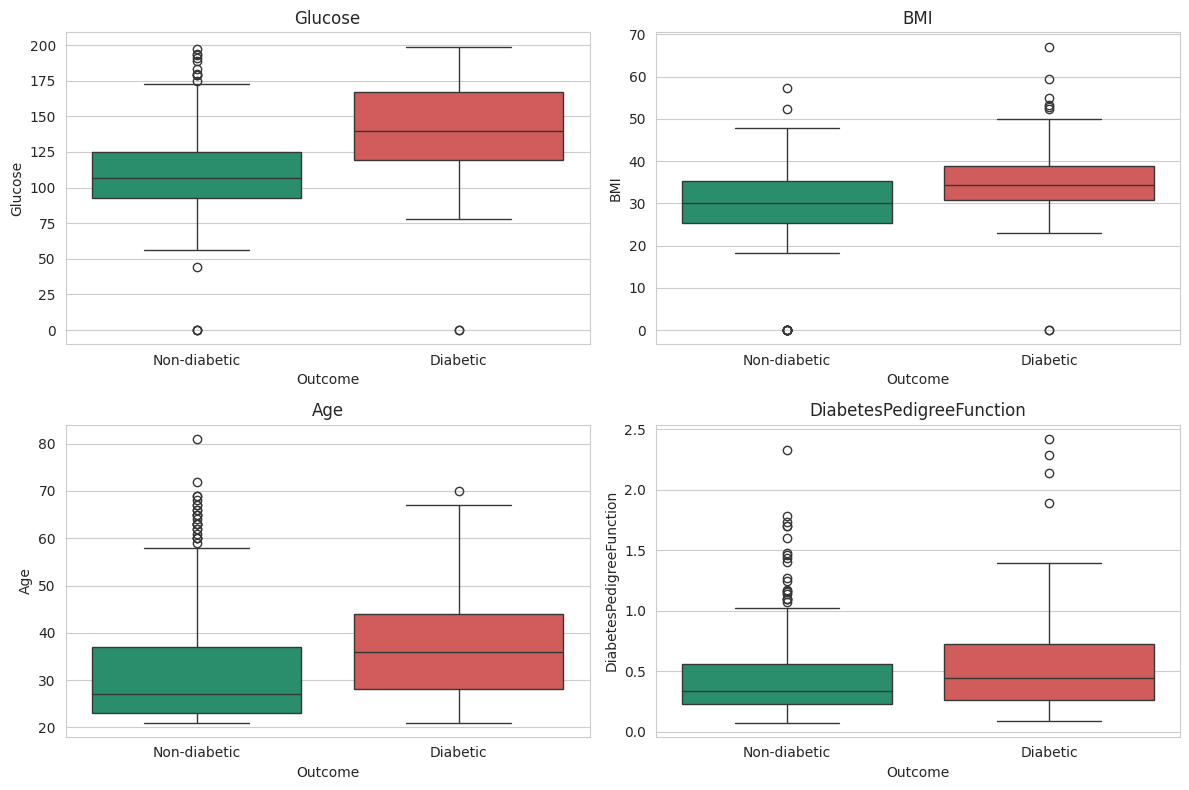

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features_to_plot = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction"]

for ax, feature in zip(axes.flat, features_to_plot):
    sns.boxplot(data=df, x="Outcome", y=feature, ax=ax, palette=["#199e70", "#e34948"])
    ax.set_xticklabels(["Non-diabetic", "Diabetic"])
    ax.set_title(feature)

plt.tight_layout()
plt.show()

Diabetic patients visibly skew higher on Glucose and BMI in particular — consistent with both the correlation heatmap above and established clinical knowledge (Section 3.1 of the paper).

## 6. Load the final model results

These come from running `src/train_models.py`, which handles the actual cleaning, training, and evaluation.

In [8]:
with open("../results/results.json") as f:
    results = json.load(f)

model_results = pd.DataFrame(results["model_results"]).T
model_results[["accuracy", "precision", "recall", "f1_score", "roc_auc"]]

,accuracy,precision,recall,f1_score,roc_auc
Logistic Regression,70.78,60.0,50.0,54.55,0.813
Random Forest,74.03,65.22,55.56,60.0,0.8161
XGBoost,77.27,70.21,61.11,65.35,0.8154


## 7. Cross-validation vs. single-split comparison

This is the most important comparison in the whole project — does the single train/test split's "winner" hold up under more rigorous testing?

In [9]:
cv_results = pd.DataFrame(results["cross_validation"]).T
comparison = pd.DataFrame({
    "Single-split accuracy": model_results["accuracy"],
    "5-fold CV mean accuracy": cv_results["mean_accuracy"],
    "5-fold CV std": cv_results["std_accuracy"],
})
comparison

,Single-split accuracy,5-fold CV mean accuracy,5-fold CV std
Logistic Regression,70.78,77.34,1.56
Random Forest,74.03,76.04,2.06
XGBoost,77.27,74.21,2.74


**Key finding:** XGBoost wins on the single split, but Logistic Regression has the highest (and most stable) average accuracy under cross-validation. This means the single-split "best model" isn't necessarily the most reliable model — a distinction that's easy to miss if you only ever look at one train/test split, and one of this project's more useful takeaways (see Section 8.4 of the paper).

## 8. Feature importance

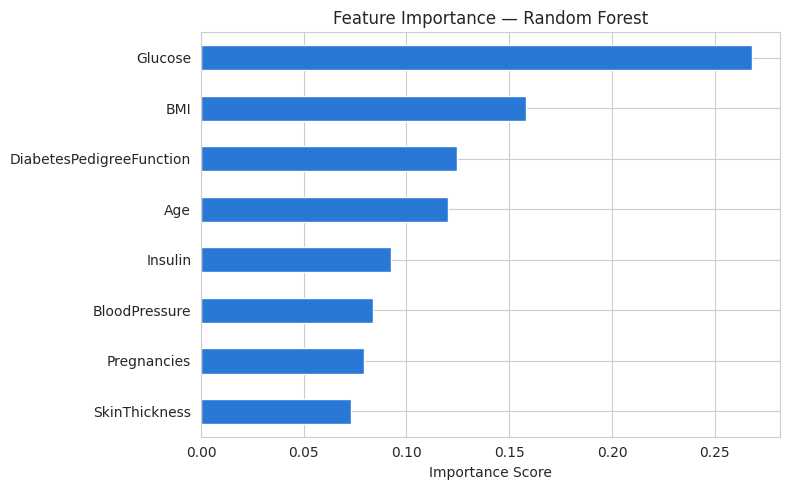

In [10]:
fi = pd.Series(results["feature_importance"]).sort_values()
fi.plot(kind="barh", color="#2a78d6")
plt.xlabel("Importance Score")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

## 9. Summary

- Glucose is overwhelmingly the strongest predictor, both by raw correlation and by the model's own feature importance — the model and the data agree.
- The dataset's class imbalance is exactly why this project didn't rely on accuracy alone.
- The single-split "winner" (XGBoost) is not the same as the cross-validated "most stable" model (Logistic Regression) — a genuinely important finding for interpreting any single reported accuracy number in this space, including the 99.41% reported in prior published work (Iparraguirre-Villanueva et al., 2023) that this project compares against.

Full discussion: see Chapter 8 of the accompanying research paper.